In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import cv2
import json
import yaml
from collections import defaultdict, Counter
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [15]:
# ============================================
# 1. ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
# ============================================

DATA_PATH = Path("data/256_yolo/defect_patches")
CLEAN_PATH = Path("data/256_yolo/clean_patches")

print("="*80)
print("АНАЛИЗ ДАТАСЕТА ДЕФЕКТОВ МЕТАЛЛА (Severstal)")
print("="*80)

# Загрузка метаданных
try:
    with open(DATA_PATH / "dataset.yaml", 'r', encoding='utf-8') as f:
        dataset_config = yaml.safe_load(f)
    with open(DATA_PATH / "annotations.json", 'r', encoding='utf-8') as f:
        annotations = json.load(f)
    metadata = pd.read_csv(DATA_PATH / "patches_metadata.csv")
except FileNotFoundError as e:
    print(f"Ошибка: Не найден файл {e}. Проверьте пути.")
    exit()

# Базовые статистики
clean_count = len(list(CLEAN_PATH.glob('*.png'))) if CLEAN_PATH.exists() else 0
print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
print(f"  Всего патчей с дефектами: {len(annotations)}")
print(f"  Всего чистых патчей: {clean_count}")
print(f"  Количество классов: {dataset_config['nc']}")

АНАЛИЗ ДАТАСЕТА ДЕФЕКТОВ МЕТАЛЛА (Severstal)

📊 ОБЩАЯ СТАТИСТИКА:
  Всего патчей с дефектами: 15987
  Всего чистых патчей: 34077
  Количество классов: 4


In [16]:
# ============================================
# 2. АНАЛИЗ РАСПРЕДЕЛЕНИЯ КЛАССОВ (БОКСЫ И ПАТЧИ)
# ============================================

print(f"\n📊 АНАЛИЗ ДИСБАЛАНСА КЛАССОВ:")

class_counts = defaultdict(int)  # Количество боксов по классам
patches_per_class = defaultdict(set)  # Количество уникальных патчей с каждым классом
total_boxes = 0
boxes_per_patch = []

# Анализ патчей и боксов
for ann in annotations:
    base_name = ann['saved_as'].replace('.jpg', '').replace('.png', '')
    
    possible_paths = [
        DATA_PATH / "labels" / f"{base_name}.txt",
        DATA_PATH / "labels" / ann.get('split', '') / f"{base_name}.txt"
    ]
    
    label_path = None
    for p in possible_paths:
        if p.exists():
            label_path = p
            break
            
    if label_path and label_path.exists():
        with open(label_path, 'r') as f:
            boxes_in_patch = 0
            classes_in_this_patch = set()
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1
                    boxes_in_patch += 1
                    total_boxes += 1
                    classes_in_this_patch.add(class_id)
            
            # Добавляем патч в статистику для каждого класса, который в нем присутствует
            for class_id in classes_in_this_patch:
                patches_per_class[class_id].add(base_name)
                    
            boxes_per_patch.append(boxes_in_patch)
    else:
        boxes_per_patch.append(0)

class_names = dataset_config['names']
class_ids = sorted(class_counts.keys())

print(f"\n  Всего обнаружено боксов: {total_boxes}")
print(f"\n  Распределение по классам:")
print(f"  {'Класс':<8} {'Название':<15} {'Боксов':<10} {'Патчей':<10} {'Боксов/патч':<12}")
print(f"  {'-'*55}")

for class_id in class_ids:
    count = class_counts[class_id]
    num_patches = len(patches_per_class[class_id])
    percentage = (count / total_boxes) * 100 if total_boxes > 0 else 0
    boxes_per_patch_avg = count / num_patches if num_patches > 0 else 0
    name = class_names[class_id] if class_id < len(class_names) else f"Unknown_{class_id}"
    print(f"  {class_id:<8} {name:<15} {count:<10} {num_patches:<10} {boxes_per_patch_avg:<12.2f}")

if total_boxes == 0:
    print("Ошибка: Не найдено ни одного бокса. Проверьте пути к labels.")
    exit()


📊 АНАЛИЗ ДИСБАЛАНСА КЛАССОВ:

  Всего обнаружено боксов: 25524

  Распределение по классам:
  Класс    Название        Боксов     Патчей     Боксов/патч 
  -------------------------------------------------------
  0        defect_type_1   3334       1568       2.13        
  1        defect_type_2   331        263        1.26        
  2        defect_type_3   18810      12402      1.52        
  3        defect_type_4   3049       2039       1.50        


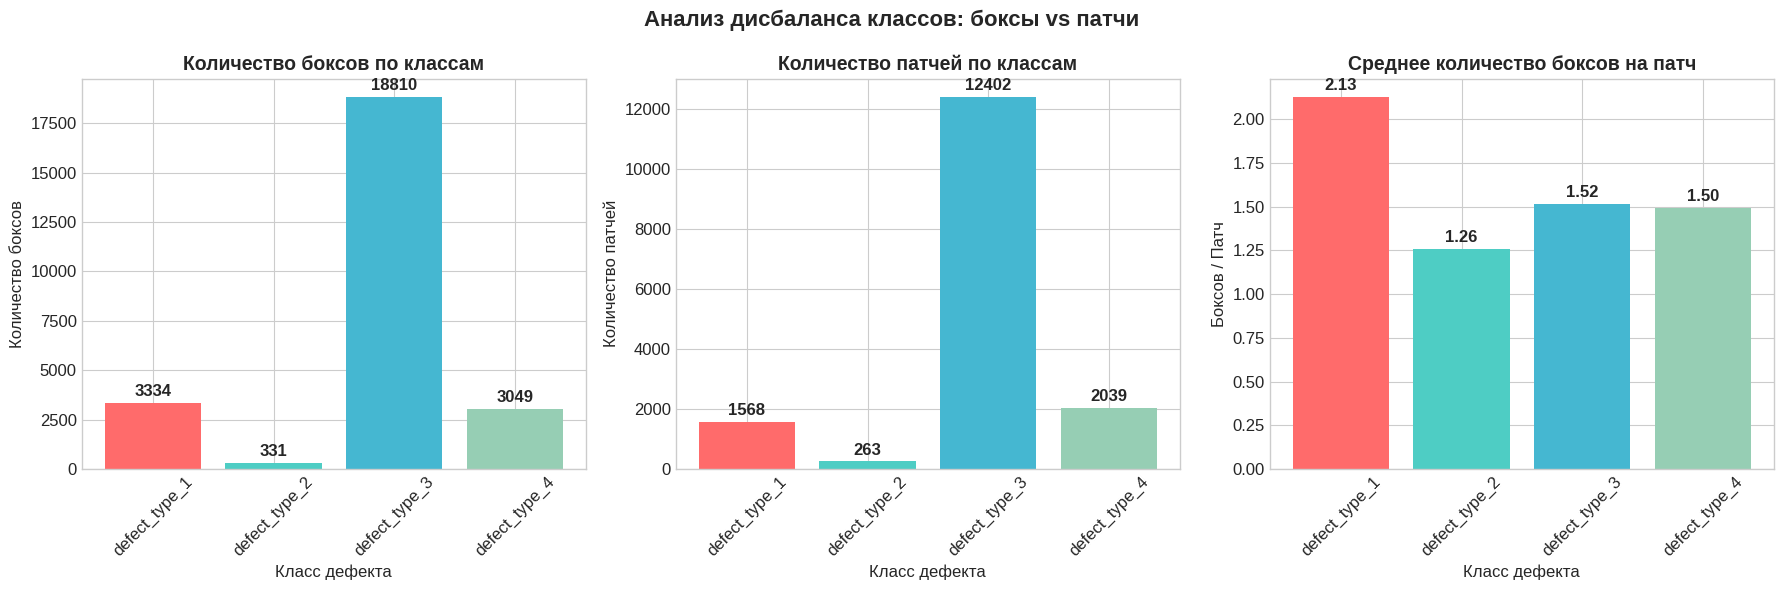

In [17]:
# ============================================
# 2.1 ВИЗУАЛИЗАЦИЯ КОЛИЧЕСТВА ПАТЧЕЙ ПО КЛАССАМ
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_names = [class_names[i] if i < len(class_names) else f"Cls_{i}" for i in class_ids]
plot_boxes = [class_counts[i] for i in class_ids]
plot_patches = [len(patches_per_class[i]) for i in class_ids]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

# График 1: Количество боксов по классам
bars1 = axes[0].bar(plot_names, plot_boxes, color=colors[:len(plot_names)])
axes[0].set_title('Количество боксов по классам', fontweight='bold')
axes[0].set_xlabel('Класс дефекта')
axes[0].set_ylabel('Количество боксов')
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars1, plot_boxes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(plot_boxes)*0.01,
                 f'{count}', ha='center', va='bottom', fontweight='bold')

# График 2: Количество патчей по классам
bars2 = axes[1].bar(plot_names, plot_patches, color=colors[:len(plot_names)])
axes[1].set_title('Количество патчей по классам', fontweight='bold')
axes[1].set_xlabel('Класс дефекта')
axes[1].set_ylabel('Количество патчей')
axes[1].tick_params(axis='x', rotation=45)

for bar, count in zip(bars2, plot_patches):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(plot_patches)*0.01,
                 f'{count}', ha='center', va='bottom', fontweight='bold')

# График 3: Среднее количество боксов на патч
avg_boxes_per_patch = [plot_boxes[i] / plot_patches[i] if plot_patches[i] > 0 else 0 for i in range(len(class_ids))]
bars3 = axes[2].bar(plot_names, avg_boxes_per_patch, color=colors[:len(plot_names)])
axes[2].set_title('Среднее количество боксов на патч', fontweight='bold')
axes[2].set_xlabel('Класс дефекта')
axes[2].set_ylabel('Боксов / Патч')
axes[2].tick_params(axis='x', rotation=45)

for bar, avg in zip(bars3, avg_boxes_per_patch):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(avg_boxes_per_patch)*0.01,
                 f'{avg:.2f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Анализ дисбаланса классов: боксы vs патчи', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH / 'class_imbalance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================
# 2.2 ВИЗУАЛИЗАЦИЯ ПЕРЕСЕЧЕНИЯ КЛАССОВ В ПАТЧАХ
# ============================================

print(f"\n📊 АНАЛИЗ СОВМЕСТНОГО ПРИСУТСТВИЯ КЛАССОВ:")

# Анализ мультиклассовых патчей
single_class_patches = 0
multi_class_patches = 0
class_cooccurrence = defaultdict(lambda: defaultdict(int))

for ann in annotations:
    base_name = ann['saved_as'].replace('.jpg', '').replace('.png', '')
    possible_paths = [
        DATA_PATH / "labels" / f"{base_name}.txt",
        DATA_PATH / "labels" / ann.get('split', '') / f"{base_name}.txt"
    ]
    label_path = None
    for p in possible_paths:
        if p.exists():
            label_path = p
            break
            
    if label_path and label_path.exists():
        with open(label_path, 'r') as f:
            classes_in_patch = set()
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    classes_in_patch.add(class_id)
            
            if len(classes_in_patch) == 1:
                single_class_patches += 1
            elif len(classes_in_patch) > 1:
                multi_class_patches += 1
                # Подсчет совместного появления
                classes_list = list(classes_in_patch)
                for i in range(len(classes_list)):
                    for j in range(i+1, len(classes_list)):
                        class_cooccurrence[classes_list[i]][classes_list[j]] += 1
                        class_cooccurrence[classes_list[j]][classes_list[i]] += 1

print(f"  Патчей с одним классом: {single_class_patches}")
print(f"  Патчей с несколькими классами: {multi_class_patches}")

if multi_class_patches > 0:
    print(f"\n  Совместное появление классов:")
    for class1 in sorted(class_cooccurrence.keys()):
        for class2 in sorted(class_cooccurrence[class1].keys()):
            if class1 < class2:
                count = class_cooccurrence[class1][class2]
                name1 = class_names[class1] if class1 < len(class_names) else f"Cls_{class1}"
                name2 = class_names[class2] if class2 < len(class_names) else f"Cls_{class2}"
                print(f"    {name1} + {name2}: {count} патчей")


📊 АНАЛИЗ СОВМЕСТНОГО ПРИСУТСТВИЯ КЛАССОВ:
  Патчей с одним классом: 15702
  Патчей с несколькими классами: 285

  Совместное появление классов:
    defect_type_1 + defect_type_2: 37 патчей
    defect_type_1 + defect_type_3: 48 патчей
    defect_type_2 + defect_type_3: 3 патчей
    defect_type_2 + defect_type_4: 1 патчей
    defect_type_3 + defect_type_4: 196 патчей


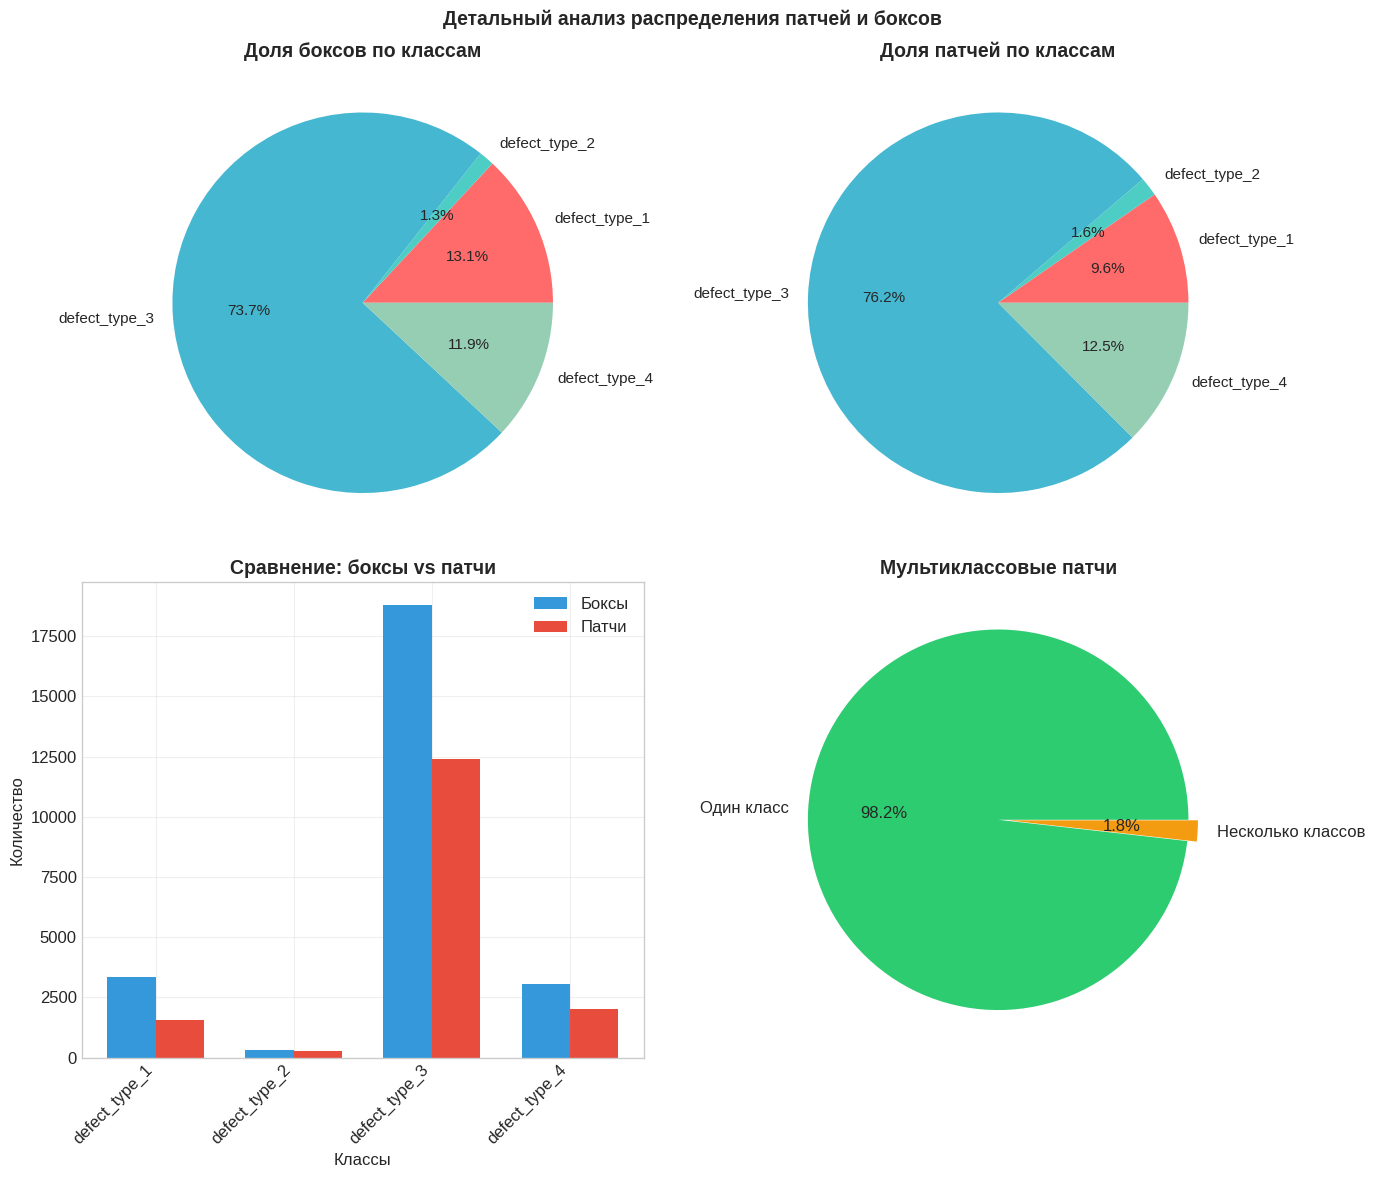

In [19]:
# ============================================
# 2.3 ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ ПАТЧЕЙ
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Pie chart для боксов
if sum(plot_boxes) > 0:
    wedges, texts, autotexts = axes[0, 0].pie(plot_boxes, labels=plot_names,
                                            autopct='%1.1f%%', colors=colors[:len(plot_names)],
                                            textprops={'fontsize': 11})
    axes[0, 0].set_title('Доля боксов по классам', fontweight='bold')

# Pie chart для патчей
if sum(plot_patches) > 0:
    axes[0, 1].pie(plot_patches, labels=plot_names,
                  autopct='%1.1f%%', colors=colors[:len(plot_names)],
                  textprops={'fontsize': 11})
    axes[0, 1].set_title('Доля патчей по классам', fontweight='bold')

# Bar chart сравнения
x = np.arange(len(plot_names))
width = 0.35

axes[1, 0].bar(x - width/2, plot_boxes, width, label='Боксы', color='#3498db')
axes[1, 0].bar(x + width/2, plot_patches, width, label='Патчи', color='#e74c3c')
axes[1, 0].set_xlabel('Классы')
axes[1, 0].set_ylabel('Количество')
axes[1, 0].set_title('Сравнение: боксы vs патчи', fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(plot_names, rotation=45, ha='right')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Круговая диаграмма мультиклассовости
multiclass_labels = ['Один класс', 'Несколько классов']
multiclass_sizes = [single_class_patches, multi_class_patches]
if sum(multiclass_sizes) > 0:
    axes[1, 1].pie(multiclass_sizes, labels=multiclass_labels, autopct='%1.1f%%',
                   colors=['#2ecc71', '#f39c12'], explode=(0, 0.05))
    axes[1, 1].set_title('Мультиклассовые патчи', fontweight='bold')

plt.suptitle('Детальный анализ распределения патчей и боксов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH / 'patches_vs_boxes_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


📊 СТАТИСТИКА ПО ПАТЧАМ:


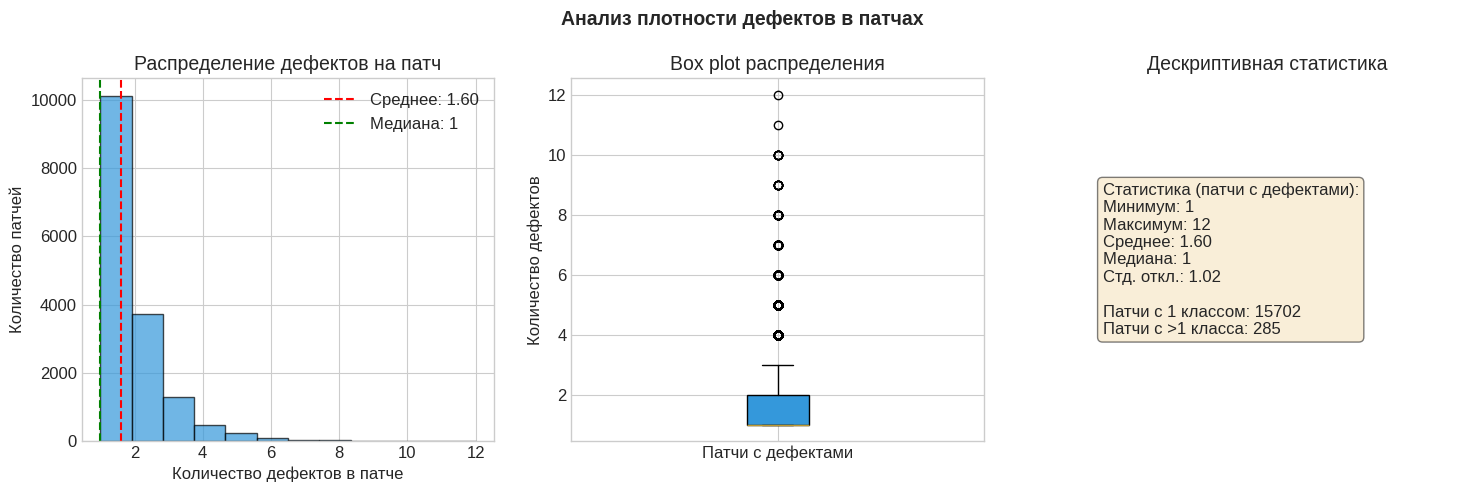

In [20]:
# ============================================
# 3. СТАТИСТИКА ПО ПАТЧАМ
# ============================================

print(f"\n📊 СТАТИСТИКА ПО ПАТЧАМ:")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

valid_boxes = [b for b in boxes_per_patch if b > 0]
if not valid_boxes:
    valid_boxes = [0]

# Гистограмма
axes[0].hist(valid_boxes, bins=min(30, len(set(valid_boxes))), edgecolor='black', alpha=0.7, color='#3498db')
axes[0].set_xlabel('Количество дефектов в патче')
axes[0].set_ylabel('Количество патчей')
axes[0].set_title('Распределение дефектов на патч')
axes[0].axvline(np.mean(valid_boxes), color='red', linestyle='--', 
                label=f'Среднее: {np.mean(valid_boxes):.2f}')
axes[0].axvline(np.median(valid_boxes), color='green', linestyle='--',
                label=f'Медиана: {np.median(valid_boxes):.0f}')
axes[0].legend()

# Box plot
bp = axes[1].boxplot(valid_boxes, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#3498db')
axes[1].set_ylabel('Количество дефектов')
axes[1].set_title('Box plot распределения')
axes[1].set_xticklabels(['Патчи с дефектами'])

# Статистика
stats_text = f"""Статистика (патчи с дефектами):
Минимум: {min(valid_boxes)}
Максимум: {max(valid_boxes)}
Среднее: {np.mean(valid_boxes):.2f}
Медиана: {np.median(valid_boxes):.0f}
Стд. откл.: {np.std(valid_boxes):.2f}

Патчи с 1 классом: {single_class_patches}
Патчи с >1 класса: {multi_class_patches}"""
axes[2].text(0.1, 0.5, stats_text, transform=axes[2].transAxes,
             fontsize=12, verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[2].axis('off')
axes[2].set_title('Дескриптивная статистика')

plt.suptitle('Анализ плотности дефектов в патчах', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH / 'defects_per_patch_stats.png', dpi=150, bbox_inches='tight')
plt.show()




📊 АНАЛИЗ РАЗМЕРОВ ДЕФЕКТОВ:


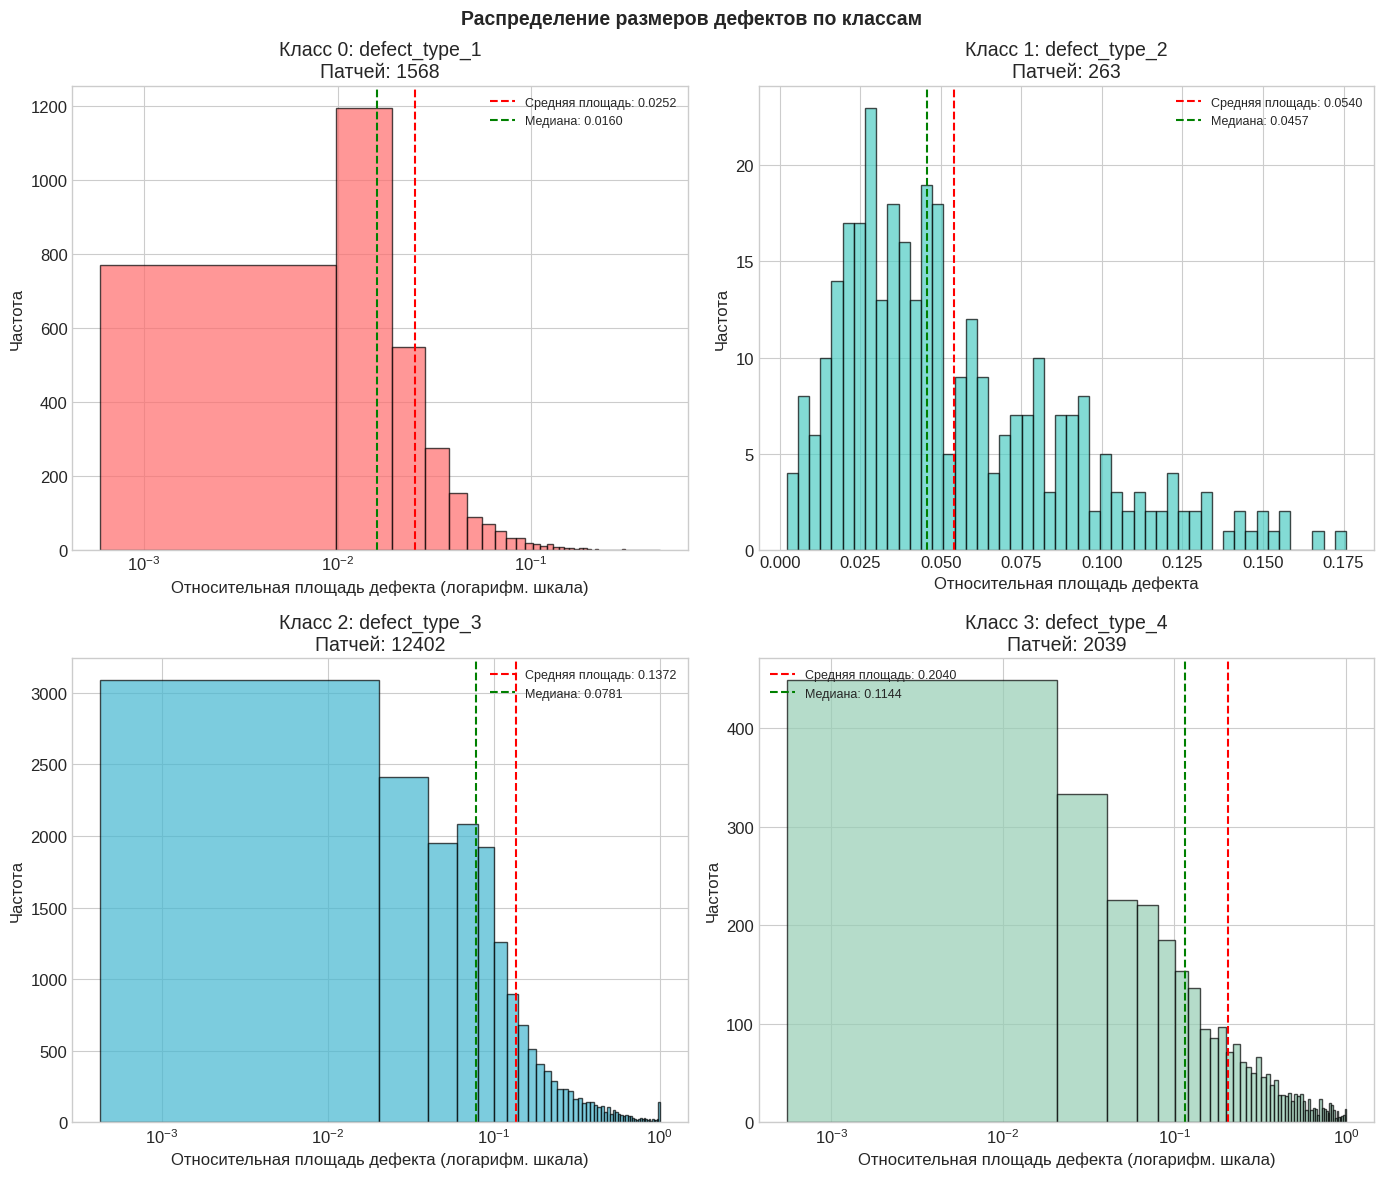

In [21]:
# ============================================
# 4. ВИЗУАЛИЗАЦИЯ РАЗМЕРОВ ДЕФЕКТОВ
# ============================================

print(f"\n📊 АНАЛИЗ РАЗМЕРОВ ДЕФЕКТОВ:")

box_sizes_by_class = defaultdict(list)
for ann in annotations:
    base_name = ann['saved_as'].replace('.jpg', '').replace('.png', '')
    possible_paths = [
        DATA_PATH / "labels" / f"{base_name}.txt",
        DATA_PATH / "labels" / ann.get('split', '') / f"{base_name}.txt"
    ]
    label_path = None
    for p in possible_paths:
        if p.exists():
            label_path = p
            break
            
    if label_path and label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                if line.strip():
                    parts = line.strip().split()
                    class_id = int(parts[0])
                    width = float(parts[3])
                    height = float(parts[4])
                    area = width * height
                    box_sizes_by_class[class_id].append(area)

if box_sizes_by_class:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for idx, class_id in enumerate(class_ids):
        if class_id not in box_sizes_by_class:
            axes[idx].text(0.5, 0.5, f'Нет данных для класса {class_id}', ha='center', va='center')
            axes[idx].set_title(f'Класс {class_id}: {class_names[class_id] if class_id < len(class_names) else "Unknown"}')
            continue
            
        areas = box_sizes_by_class[class_id]
        ax = axes[idx]
        
        ax.hist(areas, bins=50, alpha=0.7, edgecolor='black', color=colors[idx % len(colors)])
        ax.set_xlabel('Относительная площадь дефекта')
        ax.set_ylabel('Частота')
        name = class_names[class_id] if class_id < len(class_names) else f"Class_{class_id}"
        ax.set_title(f'Класс {class_id}: {name}\nПатчей: {len(patches_per_class[class_id])}')
        ax.axvline(np.mean(areas), color='red', linestyle='--', 
                   label=f'Средняя площадь: {np.mean(areas):.4f}')
        ax.axvline(np.median(areas), color='green', linestyle='--',
                   label=f'Медиана: {np.median(areas):.4f}')
        ax.legend(fontsize=9)
        
        if max(areas) > 0 and min(areas) > 0 and max(areas) / min(areas) > 100:
            ax.set_xscale('log')
            ax.set_xlabel('Относительная площадь дефекта (логарифм. шкала)')

    for idx in range(len(class_ids), 4):
        axes[idx].axis('off')

    plt.suptitle('Распределение размеров дефектов по классам', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(DATA_PATH / 'defect_sizes_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()


📊 АНАЛИЗ ЧИСТЫХ ПАТЧЕЙ:
  Количество чистых патчей: 34077
  Количество патчей с дефектами: 15987
  Соотношение дефектных/чистых: 0.47


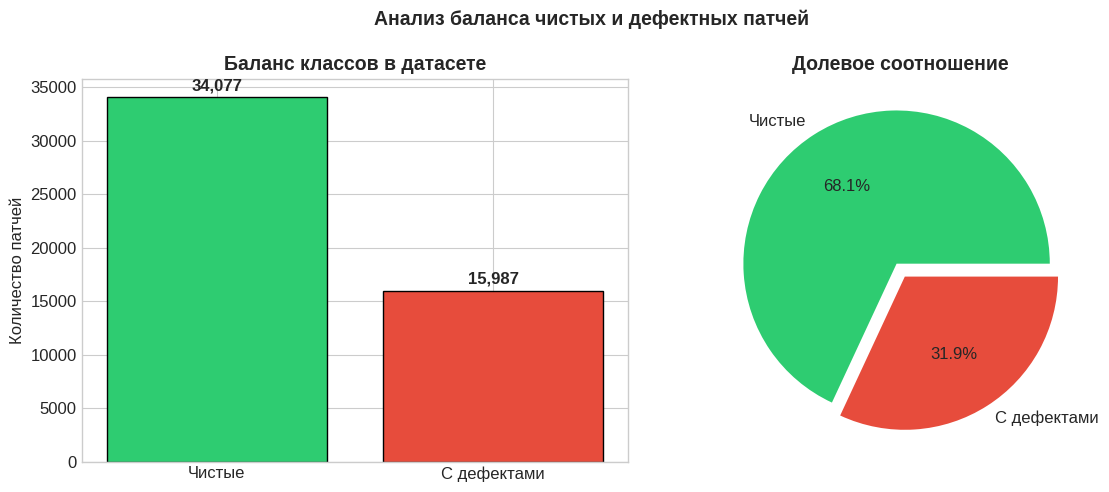

In [22]:
# ============================================
# 5. АНАЛИЗ ЧИСТЫХ ПАТЧЕЙ
# ============================================

clean_patches = list(CLEAN_PATH.glob("*.png")) if CLEAN_PATH.exists() else []
print(f"\n📊 АНАЛИЗ ЧИСТЫХ ПАТЧЕЙ:")
print(f"  Количество чистых патчей: {len(clean_patches)}")
print(f"  Количество патчей с дефектами: {len(annotations)}")
if len(clean_patches) > 0:
    print(f"  Соотношение дефектных/чистых: {len(annotations)/len(clean_patches):.2f}")
else:
    print("  Чистые патчи отсутствуют или путь указан неверно.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

categories = ['Чистые', 'С дефектами']
counts = [len(clean_patches), len(annotations)]
colors_bar = ['#2ecc71', '#e74c3c']

bars = ax1.bar(categories, counts, color=colors_bar, edgecolor='black')
ax1.set_ylabel('Количество патчей')
ax1.set_title('Баланс классов в датасете', fontweight='bold')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             f'{count:,}', ha='center', va='bottom', fontweight='bold')

if sum(counts) > 0:
    ax2.pie(counts, labels=categories, autopct='%1.1f%%', colors=colors_bar, explode=(0.05, 0.05))
    ax2.set_title('Долевое соотношение', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'Нет данных', ha='center', va='center')

plt.suptitle('Анализ баланса чистых и дефектных патчей', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH / 'clean_vs_defect_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ============================================
# 6. СТРАТЕГИЯ ДЛЯ ЭКСПЕРИМЕНТА (С УЧЕТОМ ПАТЧЕЙ)
# ============================================

print("\n" + "="*80)
print("СТРАТЕГИЯ ДЛЯ ЭКСПЕРИМЕНТА С ГЕНЕРАЦИЕЙ ДАННЫХ")
print("="*80)

ORIGINAL_DEFECTS = len(annotations)
CLEAN_PATCHES_COUNT = len(clean_patches)

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

train_size = int(ORIGINAL_DEFECTS * train_ratio)
val_size = int(ORIGINAL_DEFECTS * val_ratio)
test_size = ORIGINAL_DEFECTS - train_size - val_size

print(f"\n📊 ПЛАНИРУЕМОЕ РАЗБИЕНИЕ ДАННЫХ:")
print(f"  Train (реальные): {train_size} патчей ({train_ratio*100:.0f}%)")
print(f"  Val (реальные): {val_size} патчей ({val_ratio*100:.0f}%)")
print(f"  Test (реальные): {test_size} патчей ({test_ratio*100:.0f}%)")

SYNTHETIC_PER_REAL = 32
AUGMENTED_TRAIN_SIZE = train_size + (train_size * SYNTHETIC_PER_REAL)

print(f"\n🎯 СЦЕНАРИЙ ДЕФИЦИТА ДАННЫХ:")
print(f"  Реальных данных в train: {train_size}")
print(f"  Синтетических на каждое реальное: {SYNTHETIC_PER_REAL}")
print(f"  Всего синтетических: {train_size * SYNTHETIC_PER_REAL}")
print(f"  Размер augmented train: {AUGMENTED_TRAIN_SIZE}")
print(f"  Соотношение реальных/синтетических: 1:{SYNTHETIC_PER_REAL}")

print(f"\n⚖️  СТРАТЕГИЯ БОРЬБЫ С ДИСБАЛАНСОМ КЛАССОВ:")

total_boxes_all = sum(class_counts.values())
if total_boxes_all > 0:
    class_weights = {k: total_boxes_all/v for k, v in class_counts.items() if v > 0}
    sum_weights = sum(class_weights.values())
    normalized_weights = {k: v/sum_weights for k, v in class_weights.items()}
    
    print(f"  Веса классов для сэмплирования (на основе боксов):")
    for class_id in class_ids:
        name = class_names[class_id] if class_id < len(class_names) else f"Cls_{class_id}"
        weight = normalized_weights.get(class_id, 0)
        num_patches = len(patches_per_class[class_id])
        print(f"    Класс {class_id} ({name}): вес={weight:.3f}, патчей={num_patches}")
    
    if len(class_ids) >= 2:
        major_id = max(class_counts, key=class_counts.get)
        minor_id = min(class_counts, key=class_counts.get)
        if class_weights[minor_id] > 0 and class_weights[major_id] > 0:
            ratio = class_weights[minor_id] / class_weights[major_id]
            print(f"\n🎨 РЕКОМЕНДАЦИИ ПО ГЕНЕРАЦИИ СИНТЕТИКИ:")
            print(f"  1. Для миноритарного класса {minor_id} генерировать примерно в {ratio:.1f}x больше относительно мажоритарного.")
            
print(f"  2. Использовать аугментации: повороты, масштабирование, изменение яркости")
print(f"  3. Применять CutMix/MixUp для создания сложных случаев")
print(f"  4. Генерировать фоны с разными текстурами")


СТРАТЕГИЯ ДЛЯ ЭКСПЕРИМЕНТА С ГЕНЕРАЦИЕЙ ДАННЫХ

📊 ПЛАНИРУЕМОЕ РАЗБИЕНИЕ ДАННЫХ:
  Train (реальные): 11190 патчей (70%)
  Val (реальные): 2398 патчей (15%)
  Test (реальные): 2399 патчей (15%)

🎯 СЦЕНАРИЙ ДЕФИЦИТА ДАННЫХ:
  Реальных данных в train: 11190
  Синтетических на каждое реальное: 32
  Всего синтетических: 358080
  Размер augmented train: 369270
  Соотношение реальных/синтетических: 1:32

⚖️  СТРАТЕГИЯ БОРЬБЫ С ДИСБАЛАНСОМ КЛАССОВ:
  Веса классов для сэмплирования (на основе боксов):
    Класс 0 (defect_type_1): вес=0.081, патчей=1568
    Класс 1 (defect_type_2): вес=0.816, патчей=263
    Класс 2 (defect_type_3): вес=0.014, патчей=12402
    Класс 3 (defect_type_4): вес=0.089, патчей=2039

🎨 РЕКОМЕНДАЦИИ ПО ГЕНЕРАЦИИ СИНТЕТИКИ:
  1. Для миноритарного класса 1 генерировать примерно в 56.8x больше относительно мажоритарного.
  2. Использовать аугментации: повороты, масштабирование, изменение яркости
  3. Применять CutMix/MixUp для создания сложных случаев
  4. Генерировать фоны с

In [24]:
# ============================================
# 7. СОЗДАНИЕ ПЛАНА ЭКСПЕРИМЕНТА (С ДАННЫМИ О ПАТЧАХ)
# ============================================

experiment_plan = {
    "experiment_name": "DINOv3_finetuning_with_synthetic_data",
    "dataset_stats": {
        "total_patches_with_defects": len(annotations),
        "total_clean_patches": len(clean_patches),
        "total_boxes": total_boxes,
        "classes": {
            str(class_id): {
                "name": class_names[class_id] if class_id < len(class_names) else f"class_{class_id}",
                "boxes_count": class_counts[class_id],
                "patches_count": len(patches_per_class[class_id]),
                "avg_boxes_per_patch": class_counts[class_id] / len(patches_per_class[class_id]) if len(patches_per_class[class_id]) > 0 else 0
            }
            for class_id in class_ids
        },
        "multiclass_stats": {
            "single_class_patches": single_class_patches,
            "multi_class_patches": multi_class_patches
        }
    },
    "baseline_config": {
        "name": "Baseline (only real data)",
        "train_size": train_size,
        "val_size": val_size,
        "test_size": test_size,
        "synthetic_ratio": 0
    },
    "augmented_config": {
        "name": "Augmented (real + synthetic)",
        "train_real": train_size,
        "train_synthetic": train_size * SYNTHETIC_PER_REAL,
        "total_train": AUGMENTED_TRAIN_SIZE,
        "synthetic_ratio": SYNTHETIC_PER_REAL,
        "class_balancing": "weighted_sampling"
    },
    "evaluation_metrics": [
        "mAP@0.5",
        "mAP@0.5:0.95",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "hypothesis": """
    Использование синтетических данных позволяет:
    1. Улучшить качество извлечения признаков DINOv3
    2. Снизить влияние дисбаланса классов
    3. Улучшить обобщающую способность модели
    """
}

with open(DATA_PATH / "experiment_plan.json", 'w', encoding='utf-8') as f:
    json.dump(experiment_plan, f, indent=2, ensure_ascii=False)

print(f"\n✅ План эксперимента сохранен: {DATA_PATH / 'experiment_plan.json'}")


✅ План эксперимента сохранен: data/256_yolo/defect_patches/experiment_plan.json


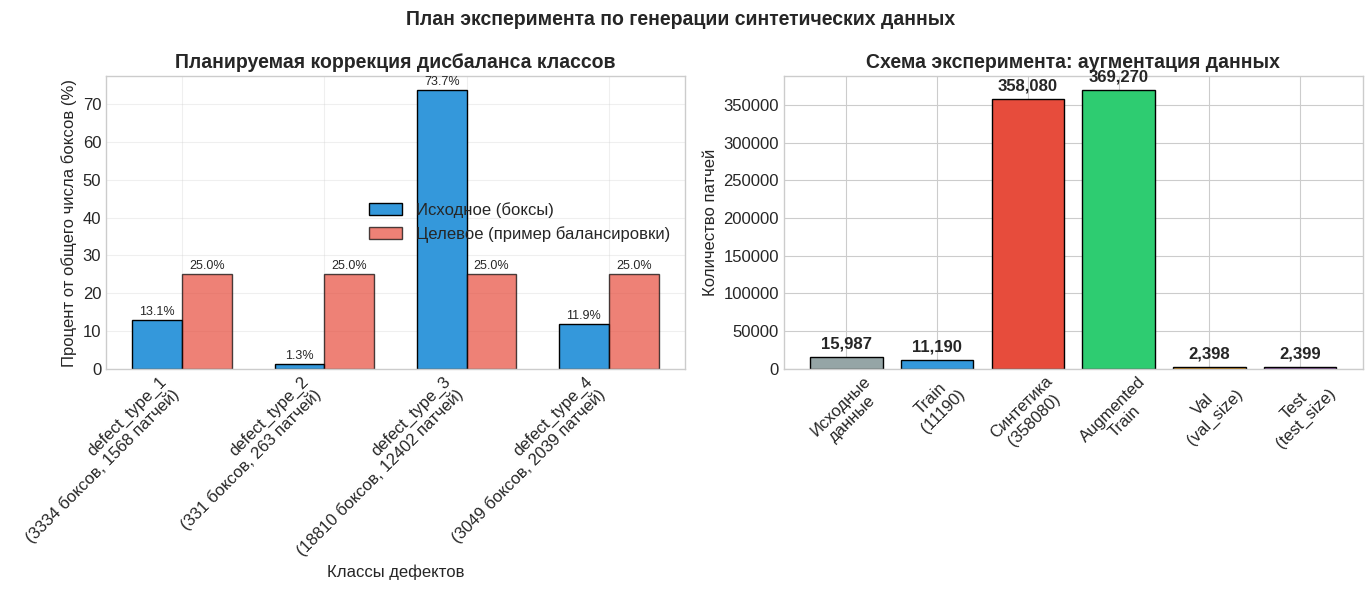

In [25]:
# ============================================
# 8. ВИЗУАЛИЗАЦИЯ СТРАТЕГИИ
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

class_counts_array = np.array([class_counts[i] for i in class_ids])
class_names_array = [f"{class_names[i] if i < len(class_names) else f'Cls_{i}'}\n({class_counts[i]} боксов, {len(patches_per_class[i])} патчей)" 
                     for i in class_ids]

target_counts = class_counts_array.copy().astype(float)
if target_counts.sum() > 0:
    target_counts = np.ones_like(target_counts) * (target_counts.sum() / len(target_counts))
    target_percent = target_counts / target_counts.sum() * 100
    orig_percent = class_counts_array / class_counts_array.sum() * 100
else:
    target_percent = np.zeros_like(class_counts_array)
    orig_percent = np.zeros_like(class_counts_array)

x = np.arange(len(class_names_array))
width = 0.35

bars1 = axes[0].bar(x - width/2, orig_percent, width, 
                     label='Исходное (боксы)', color='#3498db', edgecolor='black')
bars2 = axes[0].bar(x + width/2, target_percent, width, 
                     label='Целевое (пример балансировки)', color='#e74c3c', edgecolor='black', alpha=0.7)

axes[0].set_xlabel('Классы дефектов')
axes[0].set_ylabel('Процент от общего числа боксов (%)')
axes[0].set_title('Планируемая коррекция дисбаланса классов', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names_array, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                     f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

stages = ['Исходные\nданные', f'Train\n({train_size})', f'Синтетика\n({train_size * SYNTHETIC_PER_REAL})', 
          f'Augmented\nTrain', 'Val\n(val_size)', 'Test\n(test_size)']
sizes = [ORIGINAL_DEFECTS, train_size, train_size * SYNTHETIC_PER_REAL, 
         AUGMENTED_TRAIN_SIZE, val_size, test_size]
colors_flow = ['#95a5a6', '#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

axes[1].bar(stages, sizes, color=colors_flow, edgecolor='black')
axes[1].set_ylabel('Количество патчей')
axes[1].set_title('Схема эксперимента: аугментация данных', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

for i, (stage, size) in enumerate(zip(stages, sizes)):
    axes[1].text(i, size + max(sizes)*0.02, f'{size:,}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('План эксперимента по генерации синтетических данных', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(DATA_PATH / 'experiment_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
# ============================================
# 9. СОЗДАНИЕ СПЛИТОВ ДЛЯ ЭКСПЕРИМЕНТА (СТРАТИФИКАЦИЯ ПО КЛАССАМ)
# ============================================

print("\n📁 СОЗДАНИЕ СПЛИТОВ ДЛЯ ЭКСПЕРИМЕНТА:")

from sklearn.model_selection import train_test_split

all_patches = []
for ann in annotations:
    base_name = ann['saved_as'].replace('.jpg', '').replace('.png', '')
    possible_paths = [
        DATA_PATH / "labels" / f"{base_name}.txt",
        DATA_PATH / "labels" / ann.get('split', '') / f"{base_name}.txt"
    ]
    label_path = None
    for p in possible_paths:
        if p.exists():
            label_path = p
            break
    
    classes_in_patch = set()
    if label_path and label_path.exists():
        with open(label_path, 'r') as f:
            for line in f:
                if line.strip():
                    class_id = int(line.split()[0])
                    classes_in_patch.add(class_id)
    
    # Используем первый класс для стратификации
    primary_class = min(classes_in_patch) if classes_in_patch else -1
    
    all_patches.append({
        'path': ann['saved_as'],
        'split': ann.get('split', 'unknown'),
        'primary_class': primary_class
    })

try:
    train_val, test = train_test_split(
        all_patches, 
        test_size=test_ratio, 
        random_state=42,
        stratify=[p['primary_class'] for p in all_patches]
    )

    train, val = train_test_split(
        train_val,
        test_size=val_ratio/(train_ratio+val_ratio),
        random_state=42,
        stratify=[p['primary_class'] for p in train_val]
    )
except ValueError:
    print("  Внимание: Стратификация не удалась, используется обычное разбиение.")
    train_val, test = train_test_split(all_patches, test_size=test_ratio, random_state=42)
    train, val = train_test_split(train_val, test_size=val_ratio/(train_ratio+val_ratio), random_state=42)

print(f"\n  Train: {len(train)} патчей")
print(f"  Val: {len(val)} патчей")
print(f"  Test: {len(test)} патчей")

splits = {
    'train': [p['path'] for p in train],
    'val': [p['path'] for p in val],
    'test': [p['path'] for p in test]
}

with open(DATA_PATH / "data_splits.json", 'w', encoding='utf-8') as f:
    json.dump(splits, f, indent=2)

print(f"✅ Сплиты сохранены: {DATA_PATH / 'data_splits.json'}")


📁 СОЗДАНИЕ СПЛИТОВ ДЛЯ ЭКСПЕРИМЕНТА:

  Train: 11190 патчей
  Val: 2398 патчей
  Test: 2399 патчей
✅ Сплиты сохранены: data/256_yolo/defect_patches/data_splits.json


In [27]:
# ============================================
# 10. ИТОГОВЫЙ ОТЧЕТ (С ДАННЫМИ О ПАТЧАХ)
# ============================================

print("\n" + "="*80)
print("ИТОГОВЫЙ ОТЧЕТ ПО АНАЛИЗУ ДАННЫХ")
print("="*80)

mean_boxes = np.mean(valid_boxes) if valid_boxes else 0
median_boxes = np.median(valid_boxes) if valid_boxes else 0
min_boxes = min(valid_boxes) if valid_boxes else 0
max_boxes = max(valid_boxes) if valid_boxes else 0

# Формирование отчета с информацией о патчах
patches_info = ""
for class_id in class_ids:
    name = class_names[class_id] if class_id < len(class_names) else f"Cls_{class_id}"
    patches_info += f"     • {name}: {len(patches_per_class[class_id])} патчей, {class_counts[class_id]} боксов\n"

report = f"""
КЛЮЧЕВЫЕ ВЫВОДЫ:

1. ДИСБАЛАНС КЛАССОВ:
   - Доминирующий класс (по боксам): {max(class_counts, key=class_counts.get) if class_counts else 'N/A'}
   - Миноритарный класс (по боксам): {min(class_counts, key=class_counts.get) if class_counts else 'N/A'}
   - Доминирующий класс (по патчам): {max(patches_per_class.items(), key=lambda x: len(x[1]))[0] if patches_per_class else 'N/A'}
   - Миноритарный класс (по патчам): {min(patches_per_class.items(), key=lambda x: len(x[1]))[0] if patches_per_class else 'N/A'}
   - Необходима oversampling для миноритарных классов

2. СТАТИСТИКА ПО ПАТЧАМ И КЛАССАМ:
{patches_info}
   - Патчей с одним классом: {single_class_patches}
   - Патчей с несколькими классами: {multi_class_patches}

3. СТРУКТУРА ДАННЫХ:
   - Дефектные патчи: {len(annotations)}
   - Чистые патчи: {len(clean_patches)}
   - Соотношение: 1:{len(clean_patches)/len(annotations):.2f} (чистых больше)

4. РАСПРЕДЕЛЕНИЕ ДЕФЕКТОВ:
   - Среднее количество дефектов на патч: {mean_boxes:.2f}
   - Медиана: {median_boxes:.0f}
   - Разброс: от {min_boxes} до {max_boxes}

5. РАЗМЕРЫ ДЕФЕКТОВ:
   - Значительная вариативность размеров внутри классов
   - Требуется multi-scale подход при детекции

6. СТРАТЕГИЯ ГЕНЕРАЦИИ:
   - Синтетика:реальные = 1:{SYNTHETIC_PER_REAL}
   - Для баланса: использовать weighted sampling на основе частоты патчей

РЕКОМЕНДАЦИИ ДЛЯ ЭКСПЕРИМЕНТА:

1. При отборе патчей для генерации учитывать не только количество боксов, но и редкость класса в патчах
2. Использовать стратифицированное разбиение данных по наличию классов в патчах
3. Применить классовые веса в loss function, основанные на частоте патчей
4. Для редких классов использовать более агрессивные аугментации
5. Визуализировать t-SNE признаки DINOv3 до/после генерации
6. Сравнить baseline vs augmented на редких классах как по боксам, так и по патчам
"""

print(report)

with open(DATA_PATH / "data_analysis_report.txt", 'w', encoding='utf-8') as f:
    f.write(report)

print(f"\n✅ Все анализы сохранены в: {DATA_PATH}")
print(f"   - class_imbalance_analysis.png")
print(f"   - patches_vs_boxes_analysis.png")
print(f"   - defects_per_patch_stats.png")
print(f"   - defect_sizes_distribution.png")
print(f"   - clean_vs_defect_balance.png")
print(f"   - experiment_strategy.png")
print(f"   - experiment_plan.json")
print(f"   - data_splits.json")
print(f"   - data_analysis_report.txt")

print("\n🎉 Анализ завершен! Данные готовы для экспериментов с DINOv3")
print("\n💡 Теперь вы можете отбирать патчи на основе частоты их встречаемости по классам!")


ИТОГОВЫЙ ОТЧЕТ ПО АНАЛИЗУ ДАННЫХ

КЛЮЧЕВЫЕ ВЫВОДЫ:

1. ДИСБАЛАНС КЛАССОВ:
   - Доминирующий класс (по боксам): 2
   - Миноритарный класс (по боксам): 1
   - Доминирующий класс (по патчам): 2
   - Миноритарный класс (по патчам): 1
   - Необходима oversampling для миноритарных классов

2. СТАТИСТИКА ПО ПАТЧАМ И КЛАССАМ:
     • defect_type_1: 1568 патчей, 3334 боксов
     • defect_type_2: 263 патчей, 331 боксов
     • defect_type_3: 12402 патчей, 18810 боксов
     • defect_type_4: 2039 патчей, 3049 боксов

   - Патчей с одним классом: 15702
   - Патчей с несколькими классами: 285

3. СТРУКТУРА ДАННЫХ:
   - Дефектные патчи: 15987
   - Чистые патчи: 34077
   - Соотношение: 1:2.13 (чистых больше)

4. РАСПРЕДЕЛЕНИЕ ДЕФЕКТОВ:
   - Среднее количество дефектов на патч: 1.60
   - Медиана: 1
   - Разброс: от 1 до 12

5. РАЗМЕРЫ ДЕФЕКТОВ:
   - Значительная вариативность размеров внутри классов
   - Требуется multi-scale подход при детекции

6. СТРАТЕГИЯ ГЕНЕРАЦИИ:
   - Синтетика:реальные = 1:32
  